<a href="https://colab.research.google.com/github/DhanshreeRaut/Pattern-Recognition/blob/main/Prqactical_3_CM23059.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install required libraries (if needed)
!pip -q install wordcloud

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from wordcloud import WordCloud


In [3]:
# --------------------------------------------
# Load Dataset
# --------------------------------------------

url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"

df = pd.read_csv(url, sep='\t', header=None, names=['label','message'])

print(df.head())

  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...



Dataset Shape: (5572, 2)

Class Distribution:
label
ham     4825
spam     747
Name: count, dtype: int64


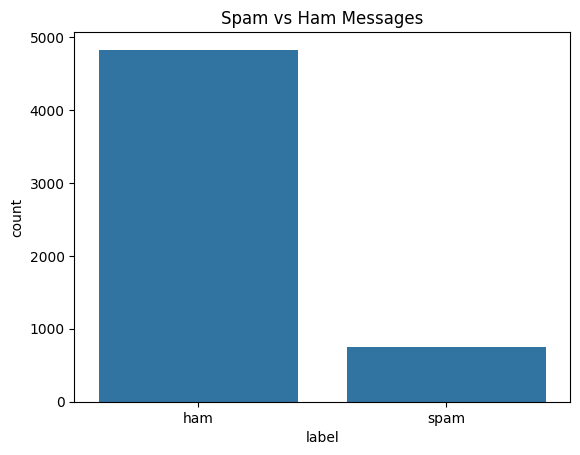

In [4]:
# --------------------------------------------
# Dataset Information
# --------------------------------------------

print("\nDataset Shape:", df.shape)
print("\nClass Distribution:")
print(df['label'].value_counts())

sns.countplot(x=df['label'])
plt.title("Spam vs Ham Messages")
plt.show()

In [5]:
# --------------------------------------------
# Convert labels to numeric
# ham = 0
# spam = 1
# --------------------------------------------

df['label_num'] = df.label.map({'ham':0,'spam':1})


In [6]:
# --------------------------------------------
# Train-Test Split
# --------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    df['message'],
    df['label_num'],
    test_size=0.25,
    random_state=42
)

In [7]:


vectorizer = CountVectorizer(stop_words='english')

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [8]:


model = MultinomialNB()

model.fit(X_train_vec, y_train)

MultinomialNB()

In [9]:
y_pred = model.predict(X_test_vec)


Accuracy: 0.9885139985642498

Classification Report

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1207
           1       0.97      0.94      0.96       186

    accuracy                           0.99      1393
   macro avg       0.98      0.97      0.97      1393
weighted avg       0.99      0.99      0.99      1393



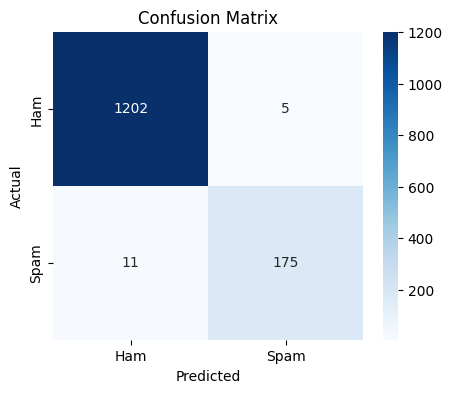

In [10]:
print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Ham','Spam'],
            yticklabels=['Ham','Spam'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [11]:
feature_names = np.array(vectorizer.get_feature_names_out())

spam_log_prob = model.feature_log_prob_[1]
ham_log_prob = model.feature_log_prob_[0]

difference = spam_log_prob - ham_log_prob

top_spam = np.argsort(difference)[-20:]
top_ham = np.argsort(difference)[:20]

print("\nTop Words Indicating SPAM\n")
for word in feature_names[top_spam][::-1]:
    print(word)

print("\nTop Words Indicating HAM\n")
for word in feature_names[top_ham]:
    print(word)


Top Words Indicating SPAM

claim
prize
150p
tone
18
guaranteed
cs
500
1000
100
awarded
uk
ringtone
www
tones
rate
150ppm
000
entry
weekly

Top Words Indicating HAM

gt
lt
da
lor
later
oh
doing
amp
said
ask
sorry
morning
come
sure
cos
feel
nice
wait
lol
ll


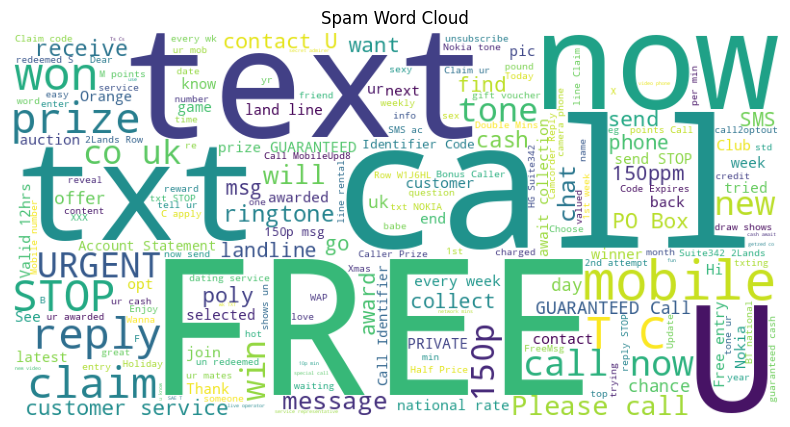

In [12]:
spam_words = " ".join(df[df.label=="spam"]["message"])

wordcloud = WordCloud(width=800,
                      height=400,
                      background_color='white').generate(spam_words)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Spam Word Cloud")
plt.show()

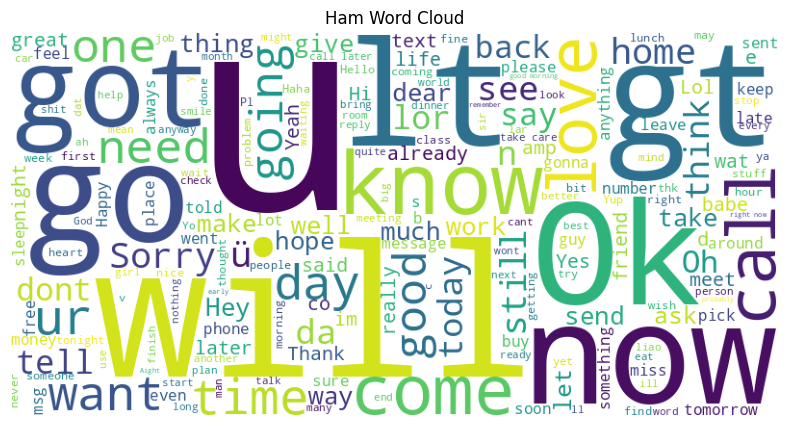

In [13]:
ham_words = " ".join(df[df.label=="ham"]["message"])

wordcloud = WordCloud(width=800,
                      height=400,
                      background_color='white').generate(ham_words)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Ham Word Cloud")
plt.show()

In [14]:
def predict_email(text):
    vec = vectorizer.transform([text])
    prediction = model.predict(vec)[0]

    if prediction == 1:
        print("Prediction: SPAM")
    else:
        print("Prediction: HAM")

print("\nExample Predictions:\n")

predict_email("Congratulations! You have won a free iPhone. Click here to claim now!")

predict_email("Hi, can we meet tomorrow for the project discussion?")


Example Predictions:

Prediction: SPAM
Prediction: HAM
